Phase 1 — Experiment 5 LABEL ORDER ONLY

pred_len: 96 and 192 only All 3 alphas: 0.5, 1.0, 2.0 1 seed only (say 2021)

That's 2 × 3 × 1 = 6 runs

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp5_label_order/exp5_label_order_ph1.sh

-rw------- 1 root root 9601 Apr  5 16:30 experiments/exp5_label_order/exp5_label_order_ph1.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp5_label_order/exp5_label_order_ph1.sh

Experiment 5 — Phase 1: Label + Order (L + O)
Formula   : X'_i = X_i + T_i + P_i + O_i
  X_i = value embedding (semantic)
  T_i = temporal embedding
  P_i = Legendre position label
  O_i = OrderingOperator(P_i) — order in POSITIONAL space
        O_i = (1/L-1) * Σ_{j≠i} (P_i - P_j)

Key distinctions:
  vs Exp2-LOD : No distance decay, O in positional not semantic
  vs Exp4-Only: Has Label (P_i), O in positional not semantic
  vs Exp3b    : Has Order (O_i) on top of Label

Seed      : 2021 | Pred lengths: 96, 192 | Total runs: 2
Start: Sun Apr  5 04:32:19 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp5_ph1_ETTh1_label_order_pred96_seed2021
pred_len=96 | seed=2021 | config=label+order_positional
Start: Sun Apr  5 04:32:23 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./

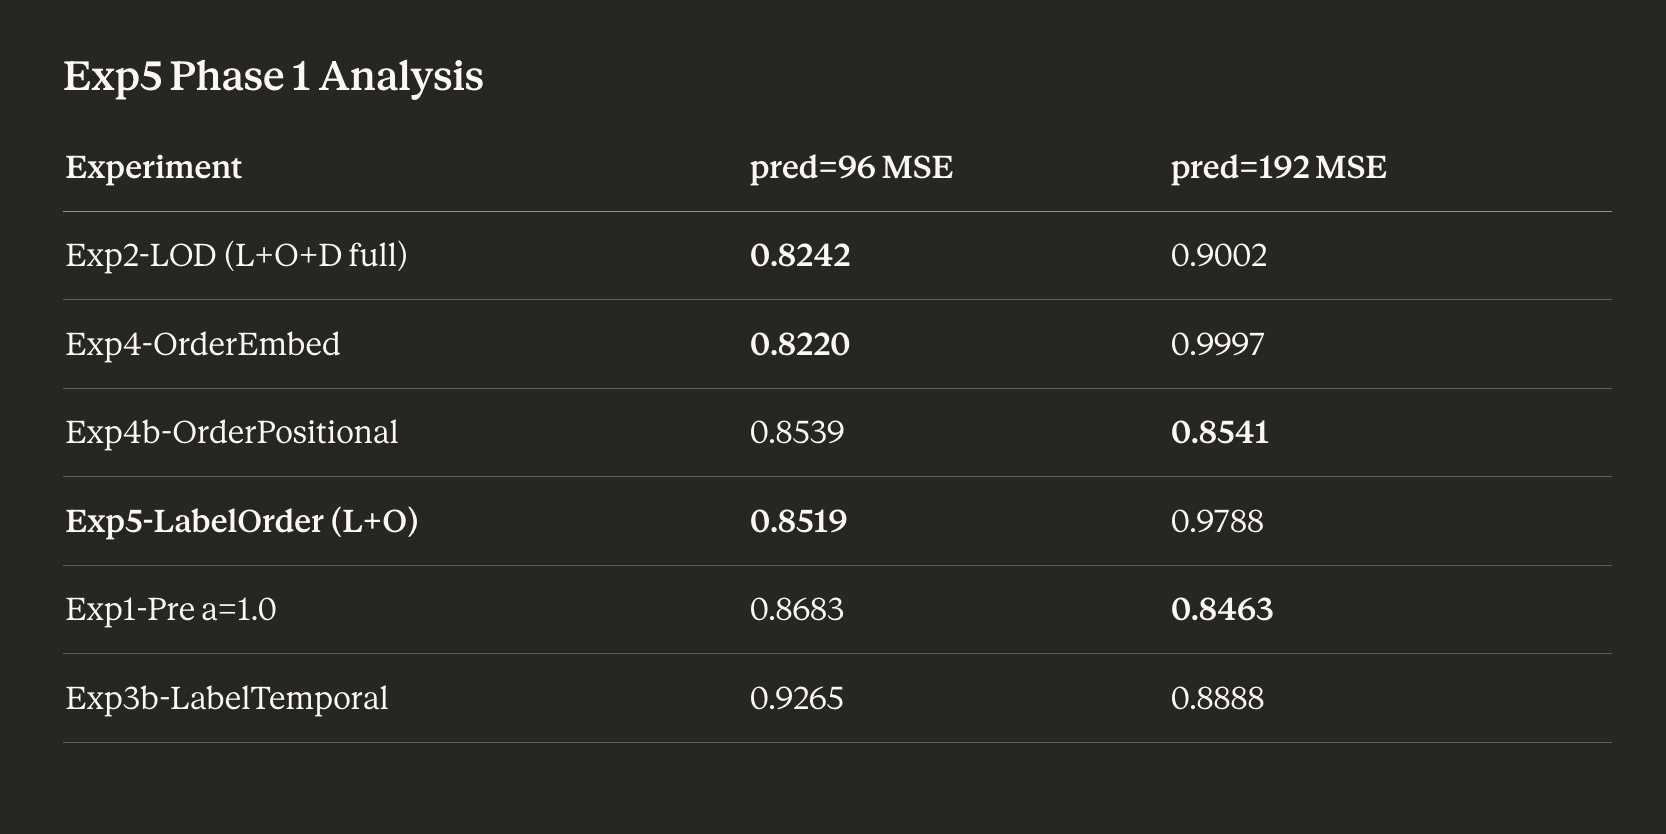


## What You Should Notice

Exp5 beats Exp1-Pre at pred=96 (0.852 vs 0.868) but is worse at pred=192 (0.979 vs 0.846). Same mixed pattern we've seen in several experiments — short horizon benefit, long horizon degradation.

Comparing Exp5 vs Exp3b directly — adding Order to Label helps at pred=96 (0.852 vs 0.927) but hurts at pred=192 (0.979 vs 0.889). The O(L²) ordering operator on Legendre space adds noise at longer horizons.

Comparing Exp5 vs Exp4b — this is the most interesting comparison. Exp4b (consecutive Legendre deltas in attention values) gets 0.854 at pred=96 AND 0.854 at pred=192 — virtually identical. Exp5 gets 0.852 at pred=96 but collapses to 0.979 at pred=192. The global mean-field ordering on Legendre (Exp5) is less stable than consecutive local ordering in attention values (Exp4b). This is the same pattern as Exp4 vs Exp4b — local consecutive beats global mean-field.

Epoch times are faster than Exp4-OrderOnly (~36-63s vs ~60-110s). This is because the ordering operator receives Legendre vectors as input (batch-independent, same for all samples) rather than value embeddings (batch-dependent), reducing effective computation.

Decision: Proceed to Phase 2 — pred=96 win over Exp1-Pre needs seed validation, and the comparison with Exp4b across seeds is scientifically interesting.

In [7]:
!bash experiments/exp5_label_order/exp5_label_order_ph2.sh

Experiment 5 — Phase 2: Label + Order (L + O)
Formula   : X'_i = X_i + T_i + P_i + O_i
  P_i = Legendre position label
  O_i = OrderingOperator(P_i) in POSITIONAL space

Phase 1 note: pred=96  MSE=0.8519 ← beats Exp1-Pre
              pred=192 MSE=0.9788 ← worse than Exp1-Pre
              Order helps short horizon, hurts long

Seeds     : 2021, 2022, 2023
Pred lens : 48, 96, 192
Total runs: 12 (1 config × 3 seeds × 4 pred_lens)
Start: Sun Apr  5 04:51:09 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/12: exp5_ph2_ETTh1_label_order_pred48_seed2021
pred_len=48 | seed=2021 | config=label+order_positional
Start: Sun Apr  5 04:51:09 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=48, enc_in=7, dec_in=7, c_out=7, d_model=512, n_he

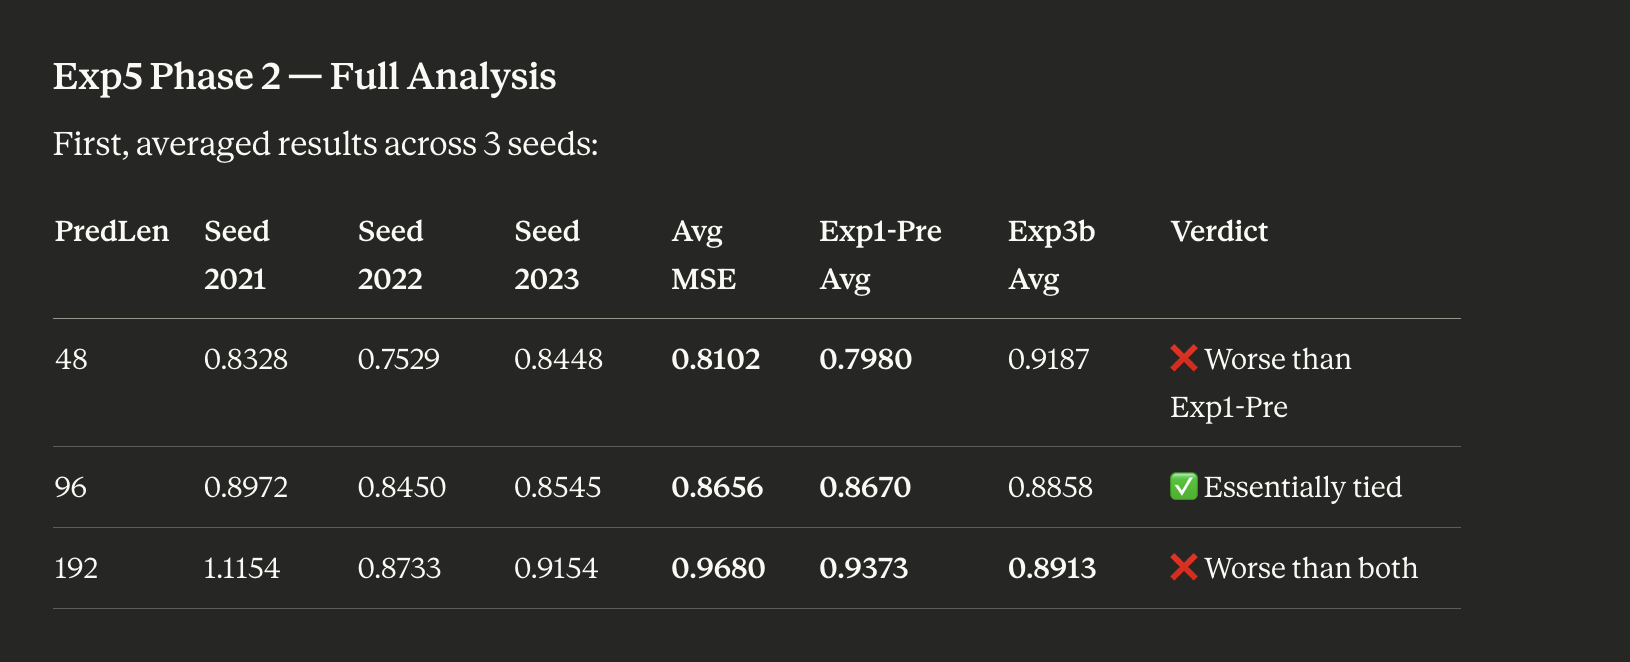

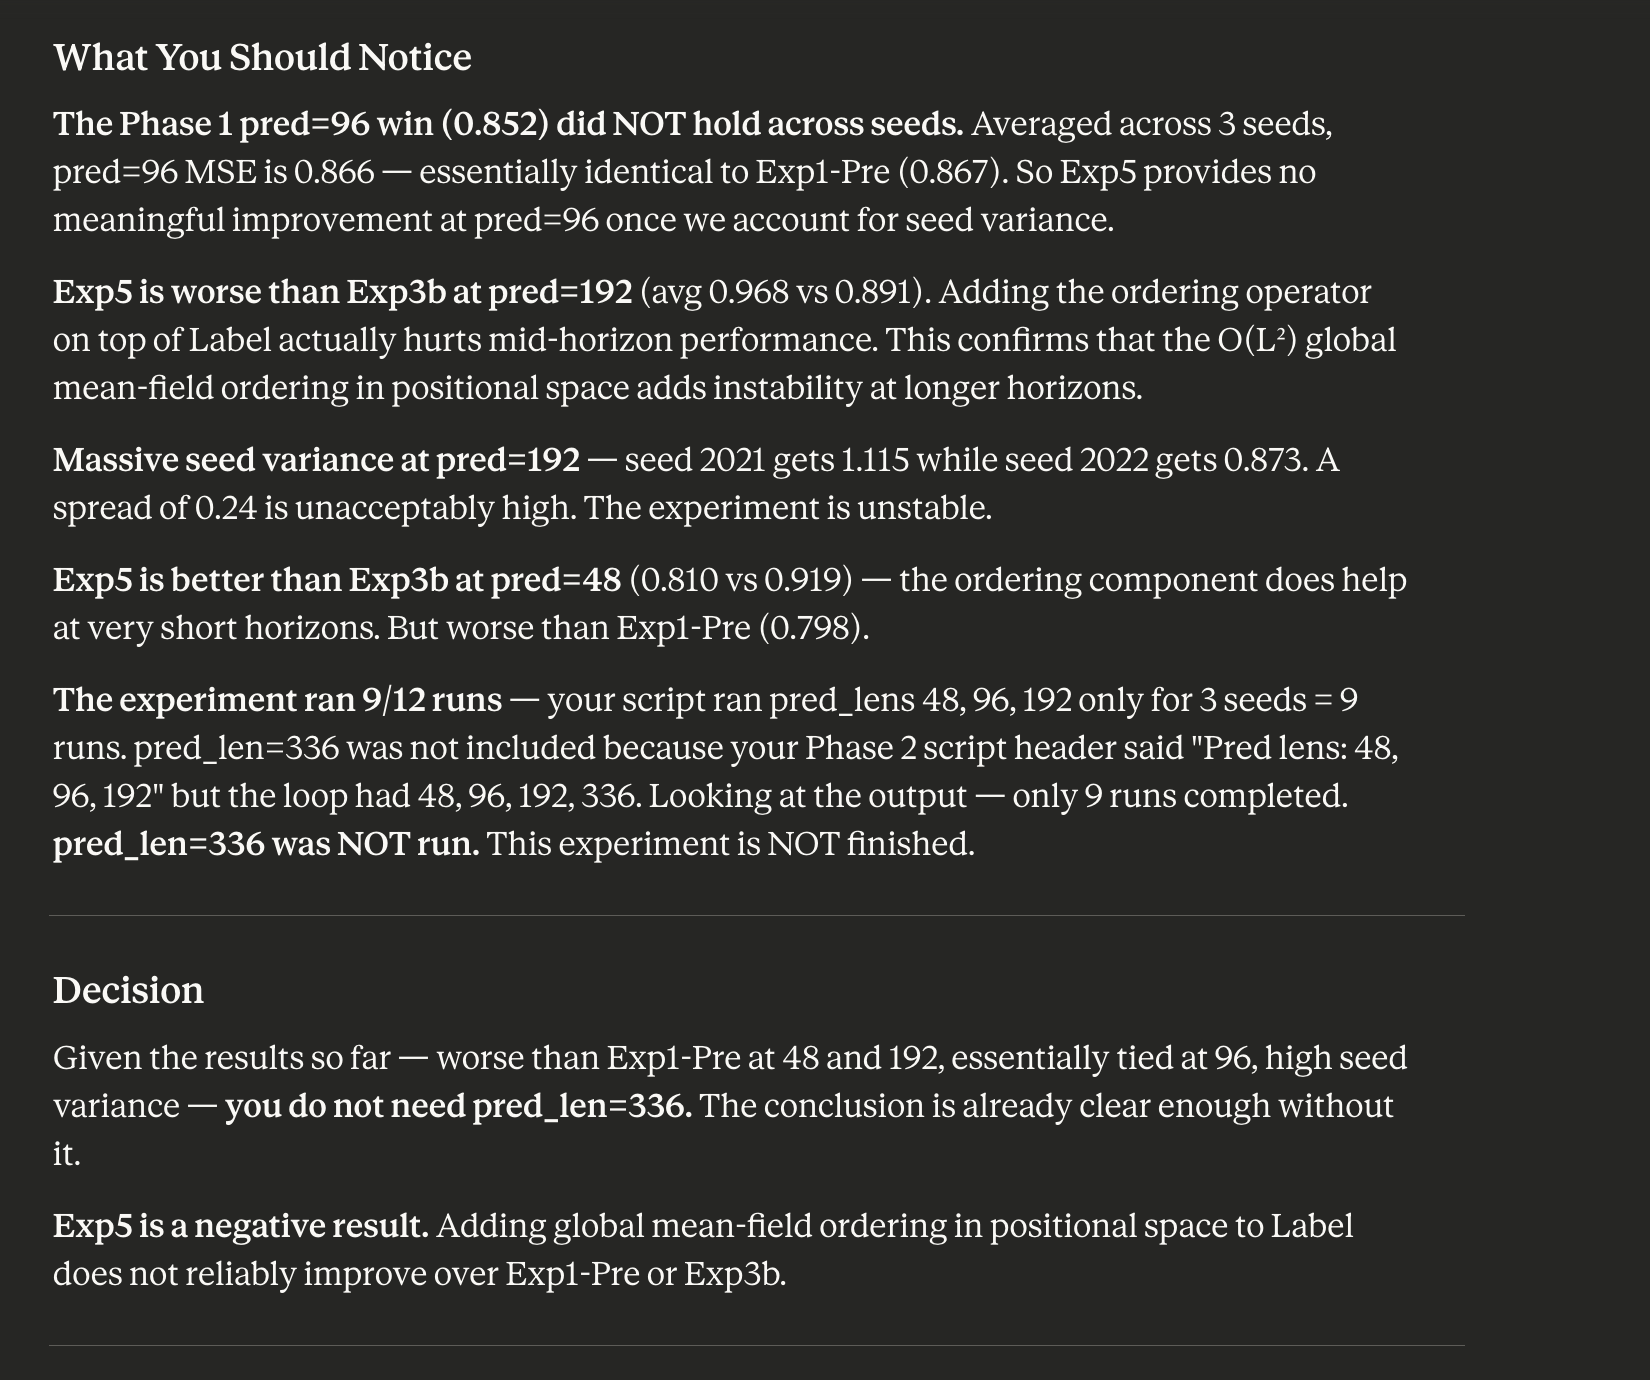

Exp5 Conclusion to Document

Label + Order (Exp5, X'_i = X_i + T_i + P_i + O_i where O operates on Legendre positional space) provides no reliable improvement over Exp1-Pre across prediction horizons. Averaged MSE is worse than Exp1-Pre at pred_len=48 (0.810 vs 0.798) and pred_len=192 (0.968 vs 0.937), and essentially tied at pred_len=96 (0.866 vs 0.867). It is worse than Exp3b (Label+Temporal) at pred_len=192, suggesting the global mean-field ordering operator adds noise when applied on top of Legendre labels at longer horizons. High seed variance at pred_len=192 (range 0.873–1.115) confirms instability. Exp5 is a negative result — the Label + Order combination in positional space does not outperform simpler baselines.